## Assignment 2

### Imports

In [2]:
import nltk
from nltk.corpus import brown
import pandas as pd
import numpy as np
import matplotlib.pylab as pl
import tensorflow as tf
from tensorflow import keras

In [3]:
nltk.download('brown')
nltk.download('universal_tagset')

[nltk_data] Downloading package brown to /usr/share/nltk_data...
[nltk_data]   Package brown is already up-to-date!
[nltk_data] Downloading package universal_tagset to
[nltk_data]     /usr/share/nltk_data...
[nltk_data]   Package universal_tagset is already up-to-date!


True

In [4]:
# glove_path_50 = "../input/glove6b50dtxt/glove.6B.50d.txt"
glove_path_100 = "./data/glove.6B.100d.txt"

### Pre-processing

In [5]:
# get statements 
statements_tags = brown.tagged_sents(tagset="universal")

In [6]:
data = []
max_len=0
for s in range(len(statements_tags)):
  g = []
  max_len = max(len(statements_tags[s]), max_len)
  for word_tag in range(len(statements_tags[s])):
    g.append([statements_tags[s][word_tag][0].lower(), statements_tags[s][word_tag][1]])
  data.append(g)

# print(data[0])
# print(max_len)

[['the', 'DET'], ['fulton', 'NOUN'], ['county', 'NOUN'], ['grand', 'ADJ'], ['jury', 'NOUN'], ['said', 'VERB'], ['friday', 'NOUN'], ['an', 'DET'], ['investigation', 'NOUN'], ['of', 'ADP'], ["atlanta's", 'NOUN'], ['recent', 'ADJ'], ['primary', 'NOUN'], ['election', 'NOUN'], ['produced', 'VERB'], ['``', '.'], ['no', 'DET'], ['evidence', 'NOUN'], ["''", '.'], ['that', 'ADP'], ['any', 'DET'], ['irregularities', 'NOUN'], ['took', 'VERB'], ['place', 'NOUN'], ['.', '.']]
180


### Glove Embeddings

In [7]:
f = open(glove_path_100) 
embedd_index = {}
for line in f:
  val = line.split()
  word = val[0]
  coff = np.asarray(val[1:],dtype = 'float')
  embedd_index[word] = coff
f.close()

In [8]:
corpus_dict = {}
id_itr = 1
for d_pt in data:
  for word, tag in d_pt:
    try:
      ind = corpus_dict[word]
      continue
    except:
      corpus_dict[word] = id_itr
      id_itr+=1
    

In [9]:
vec_size = 100

In [10]:
from nltk.downloader import itertools
def get_glove_embeddings(corpus_dict):
  glove_embeddings = np.zeros((len(corpus_dict) + 1, vec_size))
  for word,i in corpus_dict.items():
    glove_emb = embedd_index.get(word)
    if glove_emb is not None:
        glove_embeddings[i] = glove_emb
    else:
      glove_embeddings[i] = np.ones(vec_size)
  return glove_embeddings

In [11]:
glove_embeds = get_glove_embeddings(corpus_dict)

In [12]:
def get_word_embed(dp, flag):
#     if flag:
#         print("func first")
    words = [d[0] for d in dp]
    sent_len = len(words)

    pad_total = 180-sent_len
    pad_right = int(pad_total/2)
    pad_left = pad_total - pad_right

    word_vector = np.zeros((180,vec_size), dtype=float)

    for i in range(pad_left, pad_left + sent_len):
        word = words[i-pad_left].lower()
        try:
            word_vector[i,:] = embedd_index[word][:]
        except:
            word_vector[i, :] = np.ones(vec_size)
#     if flag:
#         print("func last")

    return word_vector

### Train and Test data split

In [13]:
frac = 0.8 
np.random.seed(0)
train_sz = int(frac * len(data))
indices_train = np.ones((train_sz,), dtype = int)
indices_train = np.append(indices_train, np.zeros((len(data)-train_sz,), dtype = int))
np.random.shuffle(indices_train)

In [14]:
train_data = []
test_data = []
for ind in range(len(indices_train)):
  if indices_train[ind] == 1:
    train_data.append(data[ind])
  else:
    test_data.append(data[ind])

In [15]:
print(len(train_data), len(test_data))

45872 11468


### Embeddings for training data

### Model

In [16]:
tags = ['NOUN', 'VERB', 'PRON', 'ADJ', 'ADV', 'ADP', 'CONJ', 'DET', 'NUM', 'PRT', 'X', '.']
indices_map = {'NOUN': 0,'VERB':1, 'PRON' : 2, 'ADJ' : 3, 'ADV': 4, 'ADP' : 5, 'CONJ': 6, 'DET': 7, 'NUM': 8, 'PRT' :9, 'X':10, '.':11}

In [16]:
batch_size = 64
epochs = 10
train_sz = 2000
opt = keras.optimizers.Adam(learning_rate=0.001)
input_max_len = 180
num_hid = 50

In [54]:
inputs = tf.keras.Input(shape=(input_max_len,vec_size,))
x = tf.keras.layers.Dense(num_hid, activation=tf.nn.relu)(inputs)
outputs = tf.keras.layers.Dense(12, activation=tf.nn.softmax)(x)
model = tf.keras.Model(inputs=inputs, outputs=outputs)
model.compile(loss='categorical_crossentropy', optimizer=opt)

In [55]:
print(model.summary())

Model: "model"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
input_1 (InputLayer)         [(None, 180, 100)]        0         
_________________________________________________________________
dense (Dense)                (None, 180, 50)           5050      
_________________________________________________________________
dense_1 (Dense)              (None, 180, 12)           612       
Total params: 5,662
Trainable params: 5,662
Non-trainable params: 0
_________________________________________________________________
None


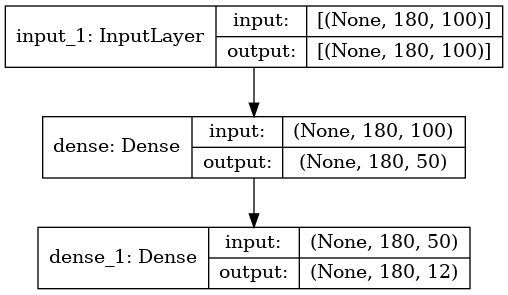

In [56]:
from keras.utils.vis_utils import plot_model
plot_model(model, to_file='model_plot.png', show_shapes=True, show_layer_names=True)

In [17]:
def get_output_embed(dp, indices_map):
  pos_tags = [d[1] for d in dp]
  sent_len = len(pos_tags)

  tag_vector = np.zeros((180,12), dtype=float)
  pad_total = 180-sent_len
  pad_right = int(pad_total/2)
  pad_left = pad_total - pad_right

  for i in range(pad_left, pad_left + sent_len):
    tag = pos_tags[i-pad_left]
    one_hot = np.zeros(12, dtype=float)
    one_hot[indices_map[tag]] = 1
    tag_vector[i,:] = one_hot

  return tag_vector

In [18]:
def perform_training(ind):
    train_word_vectors = np.zeros((train_sz, input_max_len,vec_size), dtype = float)
    print(train_sz, len(train_data)-ind)
    for i in range(min(train_sz, len(train_data)-ind)):
        if ind == 40000 and i == 5871:
            print(ind+i, i)
            train_word_vectors[i] = get_word_embed(train_data[ind+i], 1)
        train_word_vectors[i] = get_word_embed(train_data[ind+i], 0)
    train_output_vector = np.zeros((train_sz, input_max_len, 12), dtype = float)
    for i in range(min(train_sz, len(train_data)-ind)):
        train_output_vector[i] = get_output_embed(train_data[ind+i], indices_map)
    model.fit(x = train_word_vectors, y = train_output_vector, batch_size = 64, epochs = 10)


In [19]:
for ind in range(0, len(train_data), 2000):
    print("Train:",ind/2000)
    perform_training(ind)

Train: 0.0
2000 45872


NameError: name 'model' is not defined

In [47]:
model.save("model1.h5")

In [17]:
model = keras.models.load_model("./data/model.h5")

2022-10-09 06:03:00.833012: I tensorflow/stream_executor/cuda/cuda_gpu_executor.cc:937] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero
2022-10-09 06:03:00.931319: I tensorflow/stream_executor/cuda/cuda_gpu_executor.cc:937] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero
2022-10-09 06:03:00.932121: I tensorflow/stream_executor/cuda/cuda_gpu_executor.cc:937] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero
2022-10-09 06:03:00.933272: I tensorflow/core/platform/cpu_feature_guard.cc:142] This TensorFlow binary is optimized with oneAPI Deep Neural Network Library (oneDNN) to use the following CPU instructions in performance-critical operations:  AVX2 AVX512F FMA
To enable them in other operations, rebuild TensorFlow with the appropriate compil

### Inference

In [18]:
def get_prediction(test_data, test_sz, input_max_len):
    test_word_vectors = np.zeros((test_sz, 180, vec_size), dtype = float)
    results = []
    for i in range(test_sz):
        if i%1000 == 0:
            print(i)
        test_word_vectors[i] = get_word_embed(test_data[i], 0)
    obs = model.predict(test_word_vectors)
    
    for i in range(len(test_data)):
        result = []
        t_data = test_data[i]
        for j in range(len(test_data[i])):
            pad_total = 180-len(test_data[i])
            pad_right = int(pad_total/2)
            pad_left = pad_total - pad_right
            result.append([test_data[i][j][0], tags[np.argmax(obs[i][j+pad_left])]])
        results.append([t_data, result])
    return results

In [19]:
def get_word_embed_test(words):
    sent_len = len(words)
    pad_total = 180-sent_len
    pad_right = int(pad_total/2)
    pad_left = pad_total - pad_right

    word_vector = np.zeros((180,vec_size), dtype=float)

    for i in range(pad_left, pad_left + sent_len):
        word = words[i-pad_left].lower()
        try:
            word_vector[i,:] = embedd_index[word][:]
        except:
            word_vector[i, :] = np.ones(vec_size)

    return word_vector

In [20]:
def test_str(input_str, tags):
    if input_str == "":
        return []
    words = input_str.lower().split(" ")
    vector_ = get_word_embed_test(words)
    obs = model.predict(vector_.reshape(1, 180, 100))
    pad_total = 180-len(words)
    pad_right = int(pad_total/2)
    pad_left = pad_total - pad_right
    result = []
    for j in range(len(words)):
         result.append([words[j], tags[np.argmax(obs[0][j+pad_left])]])
    return result


### Testing Demo

In [23]:
input_str = "the long and lonely rd to mumbai ."
result = test_str(input_str, tags)
print("Input string:", input_str)
print(result)

Input string: the long and lonely rd to mumbai .
[['the', 'DET'], ['long', 'ADJ'], ['and', 'CONJ'], ['lonely', 'ADJ'], ['rd', 'NOUN'], ['to', 'PRT'], ['mumbai', 'NOUN'], ['.', '.']]


In [22]:
test_results = []
for i in range(0, len(test_data), 2000):
    test_results = test_results + get_prediction(test_data[i:min(2000+i, len(test_data))], min(2000, len(test_data)-i), 180)

0
1000


2022-10-09 04:27:30.208080: I tensorflow/compiler/mlir/mlir_graph_optimization_pass.cc:185] None of the MLIR Optimization Passes are enabled (registered 2)


0
1000
0
1000
0
1000
0
1000
0
1000


In [23]:
print(len(test_data[0:1000]),len(test_results))


1000 11468


In [24]:
print([j[0] for j in test_data[4]])
print(test_results[4])

['wards', 'protected']
[[['wards', 'NOUN'], ['protected', 'VERB']], [['wards', 'NOUN'], ['protected', 'VERB']]]


### Classify data w.r.t. each tag

In [25]:
def classify(test_results,tag):
       cpred_data=[]
       ctest_data=[]
       for t_data in test_results:
         for j in t_data[0]:
              if j[1]==tag:
                    cpred_data.append([j[0],j[1],1])
              else:
                    cpred_data.append([j[0],j[1],0])
         for j in t_data[1]:
              if j[1]==tag:
                    ctest_data.append([j[0],j[1],1])
              else:
                    ctest_data.append([j[0],j[1],0])
       class_results = []
       class_results.append([cpred_data,ctest_data])
       return class_results 

In [26]:
classify_data = []
for tag in tags:
    classify_data.append([tag,classify(test_results,tag)])


### Calculations of TP, FP, TN, FN

In [27]:
def measure(tag,results):
    TP = 0
    FP = 0
    TN = 0
    FN = 0
    for i in range(len(results[0])): 
        if results[1][i][2]==results[0][i][2]==1:
           TP += 1
        if results[0][i][2]==1 and results[1][i][2]!=results[0][i][2]:
           FP += 1
        if results[1][i][2]==results[0][i][2]==0:
           TN += 1
        if results[0][i][2]==0 and results[1][i][2]!=results[0][i][2]:
           FN += 1
    return[tag,TP, FP, TN, FN]

In [28]:
count = []
i=0
for result in classify_data:
        count.append(measure(tags[i],result[1][0]))
        i+=1
#print(count)
table = pd.DataFrame(count, columns = ["tag","TP", "FP","TN","FN"])
print(table)

     tag     TP    FP      TN    FN
0   NOUN  51916  2952  169215  6030
1   VERB  32162  3817  191768  2366
2   PRON   8930   630  220531    22
3    ADJ  13652  3022  211542  1897
4    ADV   9451  1756  217446  1460
5    ADP  25824  2724  199726  1839
6   CONJ   7480    77  222507    49
7    DET  26741   505  202548   319
8    NUM   2798   111  227049   155
9    PRT   4902  1001  221638  2572
10     X     69   175  229825    44
11     .  29418     0  200678    17


### Precision, Recall, F1-score

In [29]:
def metrics(tag,TP,FN,FP):
  precision = TP/(TP+FP)
  recall = TP/(TP+FN)
  F1 = 2 * precision * recall/(recall + precision)
  F2 = 5 * precision * recall/(recall + (4 * precision))
  F05 = 1.25 * precision * recall/(recall + (0.25 * precision))
  return[tag,TP,FN,FP,precision,recall,F1,F2,F05]

In [30]:
metric = []
i=0
for data in count:
  TP = data[1]
  FN = data[4]
  FP = data[2]
  metric.append(metrics(tags[i],TP,FN,FP))
  i+=1
# print(metric)
metrics_table = pd.DataFrame(metric, columns = ["tag","TP","FN","FP","precision", "recall","F1-score","F2-score","F0.5-score"])
print(metrics_table)

     tag     TP    FN    FP  precision    recall  F1-score  F2-score  \
0   NOUN  51916  6030  2952   0.946198  0.895938  0.920382  0.905558   
1   VERB  32162  2366  3817   0.893910  0.931476  0.912307  0.923712   
2   PRON   8930    22   630   0.934100  0.997542  0.964780  0.984174   
3    ADJ  13652  1897  3022   0.818760  0.877999  0.847345  0.865475   
4    ADV   9451  1460  1756   0.843312  0.866190  0.854598  0.861516   
5    ADP  25824  1839  2724   0.904582  0.933521  0.918824  0.927586   
6   CONJ   7480    49    77   0.989811  0.993492  0.991648  0.992753   
7    DET  26741   319   505   0.981465  0.988211  0.984827  0.986855   
8    NUM   2798   155   111   0.961843  0.947511  0.954623  0.950343   
9    PRT   4902  2572  1001   0.830425  0.655874  0.732900  0.684656   
10     X     69    44   175   0.282787  0.610619  0.386555  0.495690   
11     .  29418    17     0   1.000000  0.999422  0.999711  0.999538   

    F0.5-score  
0     0.935700  
1     0.901179  
2     0.9461

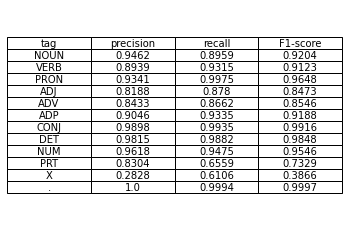

In [31]:
labels = ["tag","precision", "recall","F1-score"]
pl.figure()

metric_show = metric
met = []
mp = 0
mr = 0
mf = 0
for m in metric_show:
  mp = round(m[4], 4)
  mr = round(m[5], 4)
  mf = round(m[6], 4)
  met.append([m[0],mp,mr,mf])


# metric_np = np.around(metric_np, decimals = 4)
tb = pl.table(cellText=met, loc=(0,0), colLabels = labels, cellLoc='center')

tb.set_fontsize(10)
pl.axis("off")
tb.scale(1, 1)
pl.savefig("per_pos.jpg")

### Overall Performance

### Weighted Performance

In [32]:
prec_add=0
reca_add=0
F1_add=0
F2_add=0
F05_add=0
total=0
for metric_each in metric:
  prec_add += metric_each[4]*(metric_each[1]+metric_each[2])
  reca_add += metric_each[5]*(metric_each[1]+metric_each[2])
  F1_add += metric_each[6]*(metric_each[1]+metric_each[2])
  F2_add += metric_each[7]*(metric_each[1]+metric_each[2])
  F05_add += metric_each[8]*(metric_each[1]+metric_each[2])
  total += metric_each[1]+metric_each[2]

precision = prec_add/total
recall = reca_add/total
F1 = F1_add/total
F2 = F2_add/total
F05 = F05_add/total
print("precision: ",precision)
print("recall: ",recall)
print("F1: ",F1)
print("F2: ",F2)
print("F0.5: ",F05)

precision:  0.9279602965996231
recall:  0.9271227614259081
F1:  0.9268012060746333
F2:  0.9268247824944639
F0.5:  0.9273064760810377


### Accumulated Performance

In [33]:
TP=0
FN=0
FP=0
for data in count:
      TP += data[1]
      FN += data[4]
      FP += data[2]
precision = TP/(TP+FP)
recall = TP/(TP+FN)
F1 = 2 * precision * recall/(recall + precision)
F2 = 5 * precision * recall/(recall + (4 * precision))
F05 = 1.25 * precision * recall/(recall + (0.25 * precision))
print("precision: ",precision)
print("recall: ",recall)
print("F1: ",F1)
print("F2: ",F2)
print("F0.5: ",F05)

precision:  0.9271227614259081
recall:  0.9271227614259081
F1:  0.9271227614259081
F2:  0.927122761425908
F0.5:  0.927122761425908


### Confusion matrix

In [34]:
def build_confusion(test_results, tags):
  confusion_mat = {}
  for tag in tags:
    for t_data in test_results:
      for j in range(len(t_data[1])):
        if tag == t_data[0][j][1]:
          if (tag, t_data[1][j][1]) not in confusion_mat:
            confusion_mat[tag, t_data[1][j][1]] = 1
          else:
            confusion_mat[tag, t_data[1][j][1]] += 1
  return confusion_mat

In [35]:
tags = ['NOUN', 'VERB', 'PRON', 'ADJ', 'ADV', 'ADP', 'CONJ', 'DET', 'NUM', 'PRT', 'X', '.']
indices_map = {'NOUN': 0,'VERB':1, 'PRON' : 2, 'ADJ' : 3, 'ADV': 4, 'ADP' : 5, 'CONJ': 6, 'DET': 7, 'NUM': 8, 'PRT' :9, 'X':10, '.':11}
confusion_matrix = build_confusion(test_results,tags)

In [36]:
nx = 12
ny = 12
data_confusion = np.zeros((nx,ny))

for tag_data in confusion_matrix:
    data_confusion[indices_map[tag_data[0]]][indices_map[tag_data[1]]] = confusion_matrix[tag_data]

data_confusion = np.array([1.0*row/row.sum() for row in data_confusion])
# data_confusion = np.array([row for row in data_confusion])
data_confusion = np.around(data_confusion, decimals = 4)

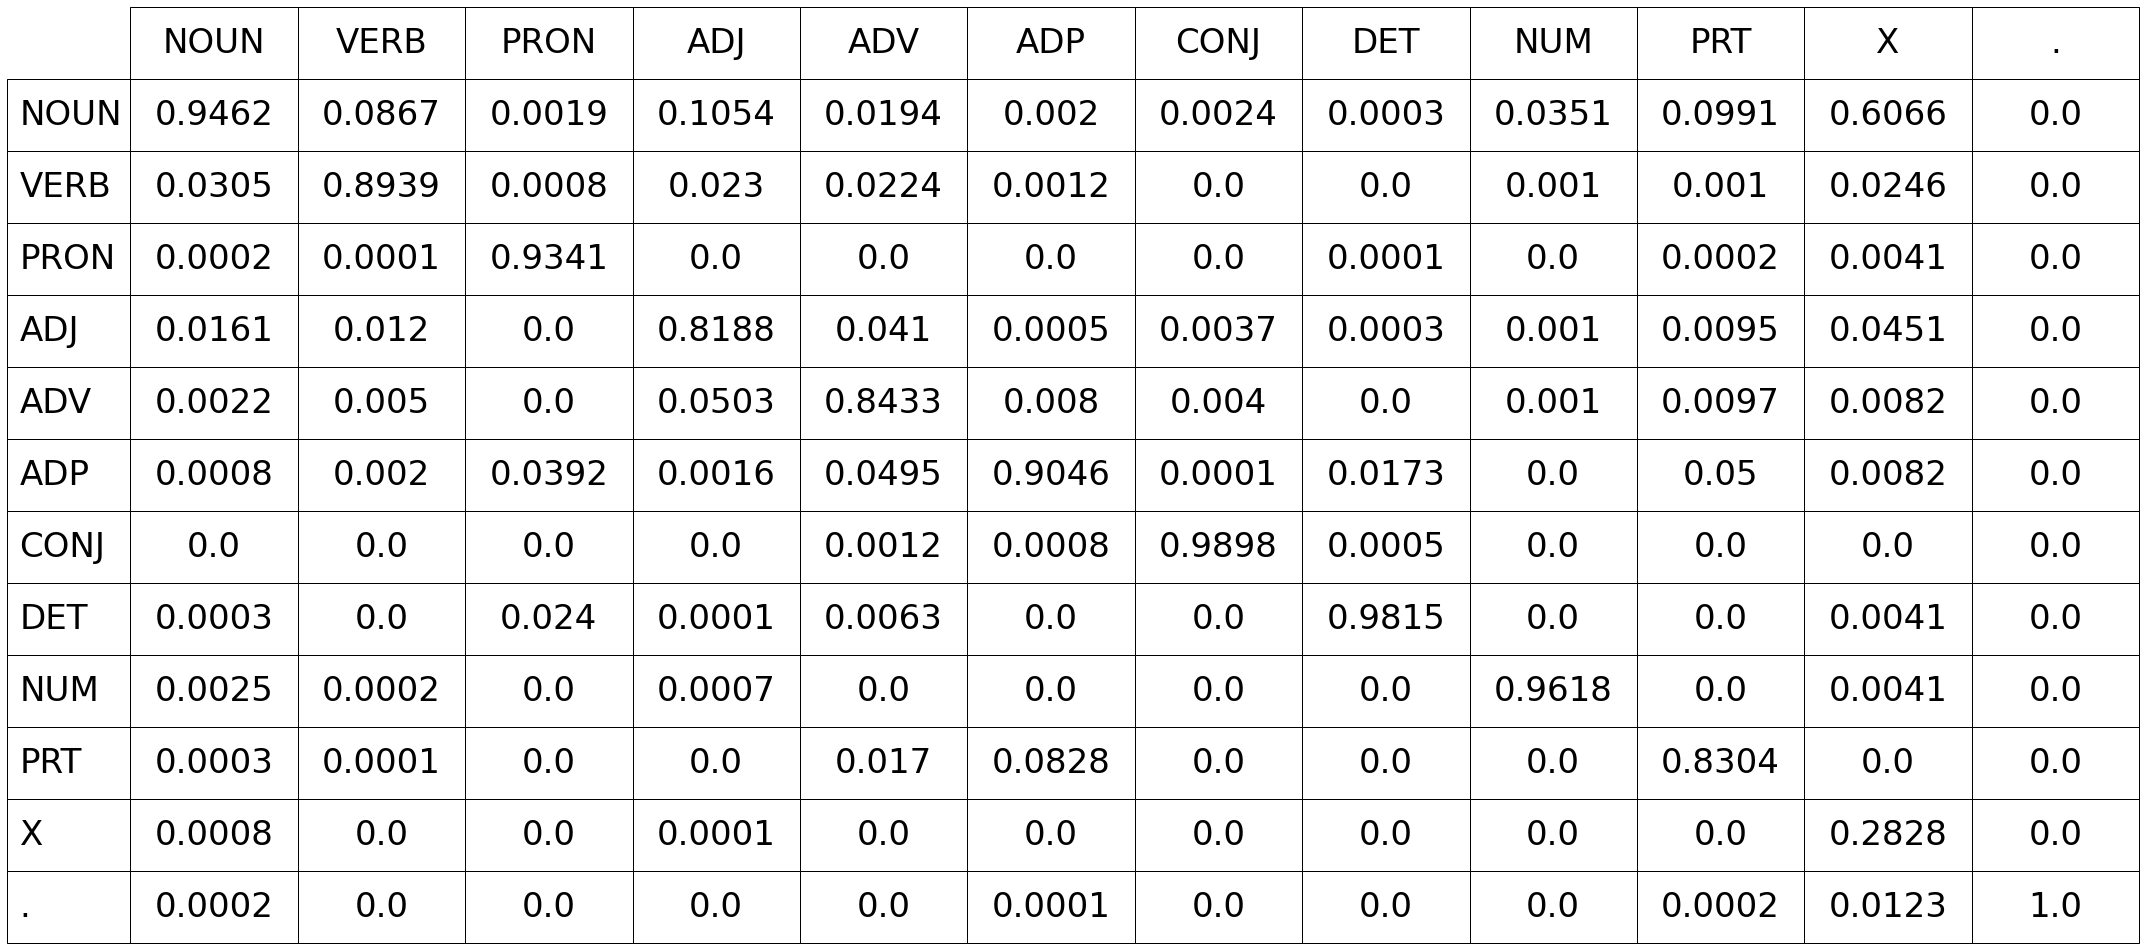

In [37]:
pl.figure()
tb = pl.table(cellText=data_confusion.T, loc=(0,0), cellLoc='center', colLabels = tags, rowLabels = tags)

tb.set_fontsize(34)
pl.axis("off")
tb.scale(6, 6)


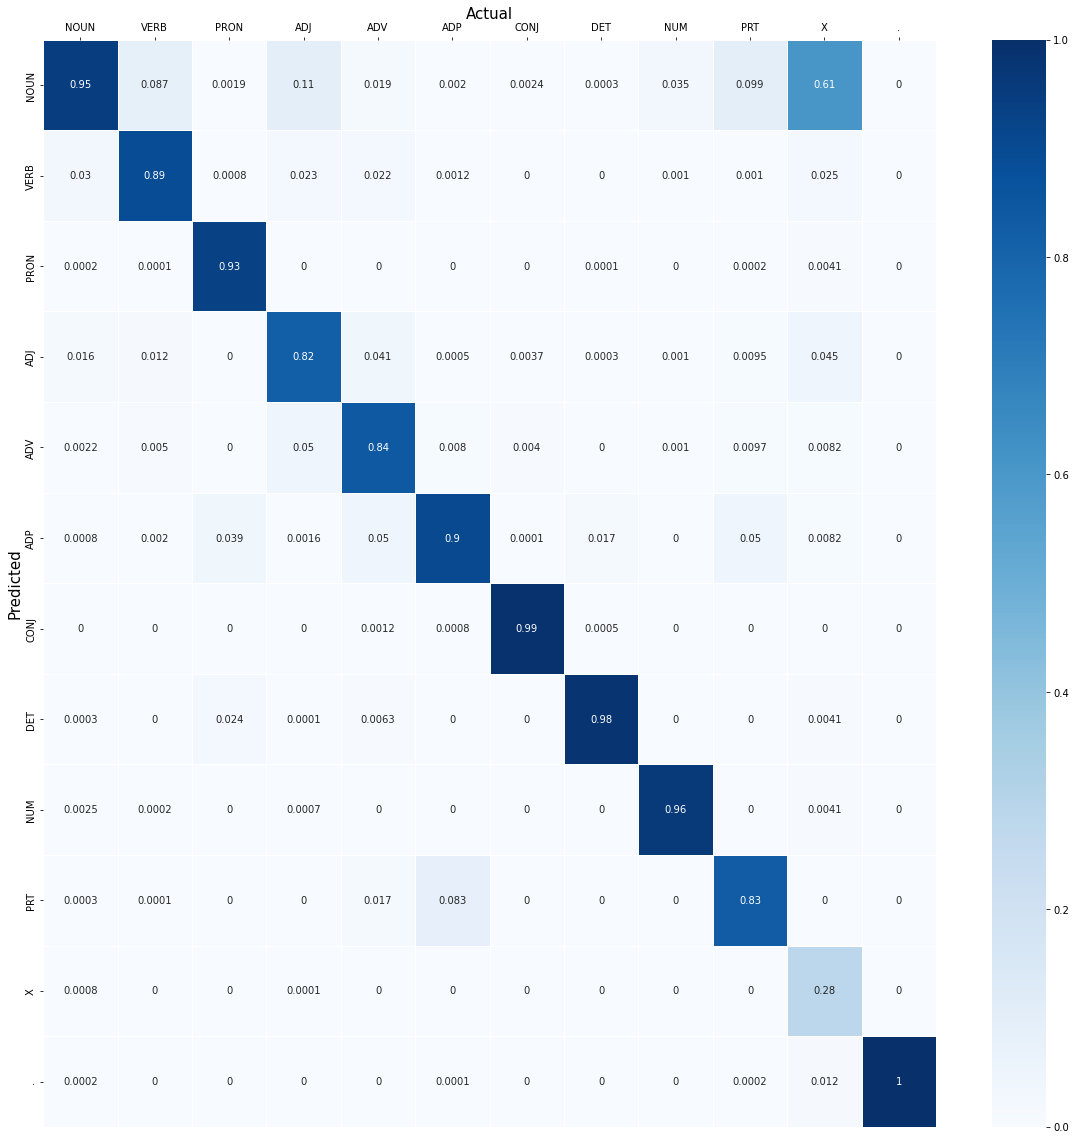

In [38]:
import seaborn as sns
pl.figure(figsize = (20,20))
ax = sns.heatmap(data_confusion.T, annot=True, cmap='Blues', linewidth = 0.5, xticklabels = tags, yticklabels = tags)
ax.set_xlabel('Actual', fontsize=15)
ax.set_ylabel('Predicted', fontsize=15)
ax.xaxis.tick_top()
ax.xaxis.set_label_position('top')
# pl.show()
pl.savefig("conf_mat.jpg")